In [1]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
import preparations as prep # dataset loading and definitions
import helper as hlp # helper functions for plotting and image processing
import importlib
importlib.reload(hlp)
importlib.reload(prep)

<module 'preparations' from '/content/preparations.py'>

In [2]:
# Libraries
import os
import pandas as pd
import numpy as np

# Imports for model building
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reporting
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imblearn.metrics import classification_report_imbalanced

# Imports for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
# List available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ TensorFlow is using a GPU:")
    for gpu in gpus:
        print("  -", gpu)
else:
    print("❌ No GPU detected. TensorFlow is using the CPU.")

✅ TensorFlow is using a GPU:
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Try with Transfer Learning with EfficientNetB1

##### Dataset loading and preprocessing

In [5]:
# Load the original dataset, if not done yet
prep.download_and_move_dataset()

Dataset already exists.


In [14]:
# Read in the images
train_ds, val_ds, class_names = hlp.read_only_xray_images(input_shape=(256,256))

Created empty directory: /tmp_546164308
Made directory: /tmp_546164308/Lung_Opacity/
Moved /COVID-19_Radiography_Dataset/Lung_Opacity/masks to /tmp_546164308/Lung_Opacity/masks
Made directory: /tmp_546164308/COVID/
Moved /COVID-19_Radiography_Dataset/COVID/masks to /tmp_546164308/COVID/masks
Made directory: /tmp_546164308/Viral Pneumonia/
Moved /COVID-19_Radiography_Dataset/Viral Pneumonia/masks to /tmp_546164308/Viral Pneumonia/masks
Made directory: /tmp_546164308/Normal/
Moved /COVID-19_Radiography_Dataset/Normal/masks to /tmp_546164308/Normal/masks
Found 21165 files belonging to 4 classes.
Using 16932 files for training.
Using 4233 files for validation.
Found classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train dataset batch: (32, 256, 256, 3) (32,)
Labels [1 1 2 2 2 2 1 2 2 2 0 2 1 2 2 2 0 2 0 2 0 1 1 1 2 1 2 1 2 2 0 2]
Validation dataset batch: (32, 256, 256, 3) (32,)
Labels [1 2 1 1 0 2 2 3 1 2 0 2 2 2 1 2 1 2 3 2 2 2 0 2 2 0 1 1 3 2 0 1]
Moved /tmp_546164308/Lun

In [15]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy())

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy())

# Let's check compatible input format for VGG16
for images, labels in train_ds.take(1):
    print('Batch shape:', images.shape, labels.shape)
    # Show some sample image shapes and according labels (should be shuffled!)
    for image, label in zip(images.numpy(),labels.numpy()):
        print(image.shape, label)

Number of batch in train_ds: 530
Number of batch in val_ds: 133
Batch shape: (32, 256, 256, 3) (32,)
(256, 256, 3) 1
(256, 256, 3) 2
(256, 256, 3) 2
(256, 256, 3) 3
(256, 256, 3) 1
(256, 256, 3) 2
(256, 256, 3) 0
(256, 256, 3) 1
(256, 256, 3) 2
(256, 256, 3) 0
(256, 256, 3) 2
(256, 256, 3) 2
(256, 256, 3) 1
(256, 256, 3) 2
(256, 256, 3) 1
(256, 256, 3) 3
(256, 256, 3) 2
(256, 256, 3) 2
(256, 256, 3) 2
(256, 256, 3) 2
(256, 256, 3) 1
(256, 256, 3) 0
(256, 256, 3) 0
(256, 256, 3) 1
(256, 256, 3) 1
(256, 256, 3) 0
(256, 256, 3) 1
(256, 256, 3) 1
(256, 256, 3) 1
(256, 256, 3) 1
(256, 256, 3) 0
(256, 256, 3) 0


In [16]:
# We have imbalanced data, hence let's calculate class_weights to give it the model
from collections import Counter

# Count occurrences of each class
class_counts = Counter()
total_count = 0
for images, labels in train_ds:
    for label in labels.numpy():  # Convert tensor to numpy
        class_counts[label] += 1
        total_count += 1

# Convert label indices to class names
class_counts_named = {class_names[idx]: count for idx, count in class_counts.items()}
print("Class Counts:", class_counts_named)

class_weights_dict = { class_label: total_count / (len(class_counts) * class_counts[class_label])
                 for class_label, class_count in class_counts.items() }
print('Class Weights:', class_weights_dict)

Class Counts: {'Viral Pneumonia': 1048, 'Lung_Opacity': 4847, 'Normal': 8134, 'COVID': 2903}
Class Weights: {np.int32(3): 4.03912213740458, np.int32(1): 0.8733237053847741, np.int32(2): 0.5204081632653061, np.int32(0): 1.4581467447468137}


#### Try with EfficientNetB1 (pretrained)

In [ ]:
# Make sure, the models folder exists
if not os.path.exists(os.path.join('..', 'models')):
    os.makedirs(os.path.join('..', 'models'))

# This model name for saving and loading
model_name = os.path.join('..', 'models', '3d_efficientnetb1_dense128.keras')

In [19]:
# Imports for using a pre-trained model
from tensorflow.keras.applications import EfficientNetB1

# EfficientNetB1 model
base_model = EfficientNetB1(include_top=False, input_shape=(256, 256, 3))

# Freeze the layers of the base model
base_model.trainable = False

# Model creation using the Functional API
inputs = Input(shape=(256, 256, 3))

# Build the model
x = base_model(inputs)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(rate=0.2)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(rate=0.2)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

effnet = Model(inputs=inputs, outputs=outputs)

In [20]:
# Applied Callbacks
early_stopping = EarlyStopping(
                                patience=5, # Wait for 5 epochs before applying
                                min_delta=0.01, # If the loss function doesn't change by 1% after 5 epochs, either up or down, we stop
                                verbose=1, # Display the epoch at which training stops
                                mode='min',
                                monitor='val_loss')

# A learning rate reduction callback to reduce the learning rate when the validation loss stagnates
reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # If val_loss stagnates for 3 consecutive epochs based on the min_delta value
                                    min_delta=0.01,
                                    factor=0.1,  # Reduce the learning rate by a factor of 0.1
                                    cooldown=3,  # Wait 3 epochs before retrying
                                    verbose=1)

In [21]:
# Compile with first idea of appropriate parameters
effnet.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Print how it looks like
effnet.summary()

# Convert summary to DataFrame and display it (for copy and paste purposes)
df_summary = hlp.model_summary_to_df(effnet)
display(df_summary)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb1 (Functional)          │ (None, 8, 8, 1280)          │       6,575,239 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1024)                │       1,311,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,018,699 (30.59 MB)

 Trainable params: 1,443,460 (5.51 MB)

 Non-trainable params: 6,575,239 (25.08 MB)

,Layer Name (type),Output Shape,Param Count
0,input_layer_3 (InputLayer),"(None, 256, 256, 3)",0
1,efficientnetb1 (Functional),"(None, 8, 8, 1280)","6,575,239"
2,global_average_pooling2d_1,"(None, 1280)",0
3,(GlobalAveragePooling2D),,
4,dense_3 (Dense),"(None, 1024)","1,311,744"
5,dropout_2 (Dropout),"(None, 1024)",0
6,dense_4 (Dense),"(None, 128)","131,200"
7,dropout_3 (Dropout),"(None, 128)",0
8,dense_5 (Dense),"(None, 4)",516


In [22]:
# Train it with the entire dataset (takes very long!)
history_model = effnet.fit(train_ds,
                          epochs=25,
                          validation_data=val_ds,
                          class_weight=class_weights_dict,
                          callbacks=[early_stopping, reduce_learning_rate])

Epoch 1/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 104s 110ms/step - accuracy: 0.7525 - loss: 0.5400 - val_accuracy: 0.8717 - val_loss: 0.3308 - learning_rate: 0.0010
Epoch 2/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8492 - loss: 0.3266 - val_accuracy: 0.8824 - val_loss: 0.3258 - learning_rate: 0.0010
Epoch 3/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8693 - loss: 0.2779 - val_accuracy: 0.8826 - val_loss: 0.3051 - learning_rate: 0.0010
Epoch 4/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8780 - loss: 0.2547 - val_accuracy: 0.8930 - val_loss: 0.2999 - learning_rate: 0.0010
Epoch 5/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8918 - loss: 0.2331 - val_accuracy: 0.8880 - val_loss: 0.3004 - learning_rate: 0.0010
Epoch 6/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8921 - loss: 0.2178 - val_accuracy: 0.9017 - val_loss: 0.2755 - learning_rate: 0.0010
Epoch 7/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9003 -

In [23]:
# Save the model for potential later use
effnet.save(model_name)

##### Evalution

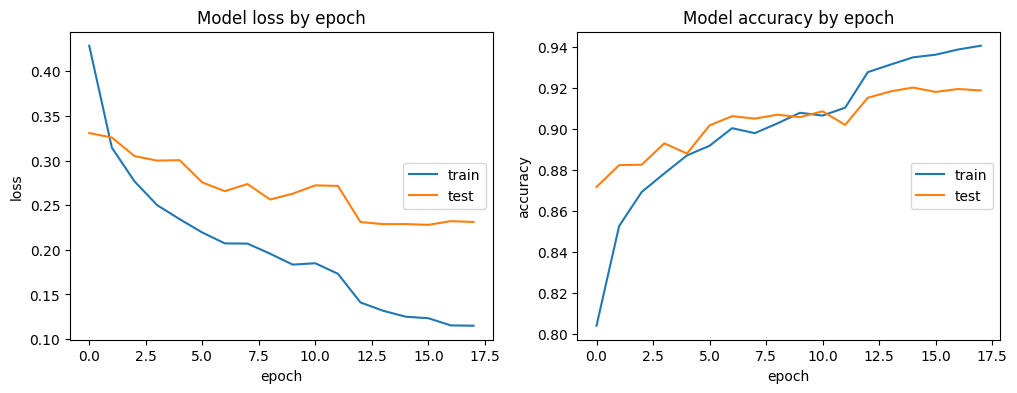

In [24]:
hlp.plot_learning_curve(history_model)

> We can see, that our model accuracy stagnates at appr. 70%
> It seems, that we cannot improve here much.

In [25]:
from tensorflow import keras
effnet = keras.models.load_model(model_name)

In [26]:
#y_true, y_pred = get_predictions_and_labels(vgg16, val_ds.take(8)) # for a quick result
y_true, y_pred = hlp.get_predictions_and_labels(effnet, val_ds)

,pre,rec,spe,f1,geo,iba,sup
COVID,0.958924,0.949509,0.991761,0.954193,0.970405,0.937708,713.000000
Lung_Opacity,0.882753,0.891845,0.955020,0.887276,0.922892,0.846349,1165.000000
Normal,0.927693,0.916424,0.932414,0.922024,0.924384,0.853120,2058.000000
Viral Pneumonia,0.905363,0.966330,0.992378,0.934853,0.979267,0.956467,297.000000
avg_pre,0.919018,0.919018,0.919018,0.919018,0.919018,0.919018,0.919018
avg_rec,0.918734,0.918734,0.918734,0.918734,0.918734,0.918734,0.918734
avg_spe,0.952839,0.952839,0.952839,0.952839,0.952839,0.952839,0.952839
avg_f1,0.918779,0.918779,0.918779,0.918779,0.918779,0.918779,0.918779
avg_geo,0.935576,0.935576,0.935576,0.935576,0.935576,0.935576,0.935576
avg_iba,0.872755,0.872755,0.872755,0.872755,0.872755,0.872755,0.872755


Predicted,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,677,10,22,4
Lung_Opacity,11,1039,115,0
Normal,18,128,1886,26
Viral Pneumonia,0,0,10,287


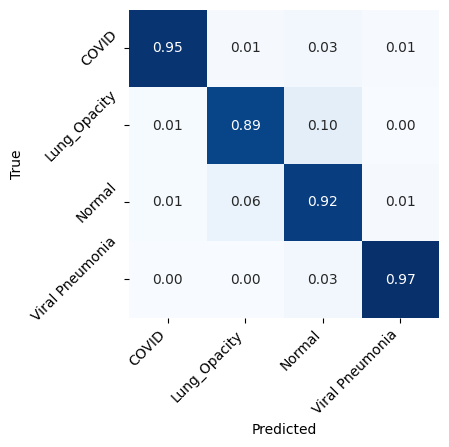

{'crosstab': Predicted        COVID  Lung_Opacity  Normal  Viral Pneumonia
 COVID              677            10      22                4
 Lung_Opacity        11          1039     115                0
 Normal              18           128    1886               26
 Viral Pneumonia      0             0      10              287,
 'classification_report':                          pre          rec          spe           f1  \
 COVID               0.958924     0.949509     0.991761     0.954193   
 Lung_Opacity        0.882753     0.891845     0.955020     0.887276   
 Normal              0.927693     0.916424     0.932414     0.922024   
 Viral Pneumonia     0.905363     0.966330     0.992378     0.934853   
 avg_pre             0.919018     0.919018     0.919018     0.919018   
 avg_rec             0.918734     0.918734     0.918734     0.918734   
 avg_spe             0.952839     0.952839     0.952839     0.952839   
 avg_f1              0.918779     0.918779     0.918779     0.918779   

In [27]:
hlp.report_model_performance(y_true, y_pred, class_names)

# Conclusion: Our model predicts the 4 classes already not too bad
# However, the recall especially for the covid class is the lowest